# Notebook 04 — Fully Connected MNIST Network

This notebook moves from the manually derived tiny network in Notebook 03 to a
practical neural network trained with **PyTorch**, applied to the real single-digit
MNIST task.

```text
28 x 28 image
      |
      v
   flatten
      |
      v
fully connected layers
      |
      v
10 output scores
      |
      v
Softmax probabilities
      |
      v
predicted digit
```

PyTorch handles the forward/backward mechanics here; the goal of this notebook is to
understand every tensor shape, activation, loss, and optimizer choice, not to derive
gradients by hand again.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import torch

from classical.data_utils import get_MNIST_data, plot_images
from neural_networks.train_utils import batchify_data, train_model, run_epoch
from neural_networks.fully_connected import build_fully_connected_model

np.random.seed(12321)
torch.manual_seed(12321)

## 1. Prepare MNIST tensors

We reuse the same `get_MNIST_data` loader as the classical notebooks, so the
comparison later in this project uses an identical dataset. Unlike Notebook 01,
here we split off a dedicated validation set from the training data and batch
everything into fixed-size mini-batches for stochastic gradient descent.

In [2]:
train_x, train_y, test_x, test_y = get_MNIST_data()
print("train_x:", train_x.shape, " test_x:", test_x.shape)

dev_split_index = int(9 * len(train_x) / 10)
permutation = np.random.permutation(len(train_x))
train_x, train_y = train_x[permutation], train_y[permutation]

X_dev, y_dev = train_x[dev_split_index:], train_y[dev_split_index:]
X_train, y_train = train_x[:dev_split_index], train_y[:dev_split_index]

batch_size = 32
train_batches = batchify_data(X_train, y_train, batch_size)
dev_batches = batchify_data(X_dev, y_dev, batch_size)
test_batches = batchify_data(test_x, test_y, batch_size)

print("train batches:", len(train_batches))
print("dev batches:  ", len(dev_batches))
print("test batches: ", len(test_batches))

example_batch = train_batches[0]
print("one batch of x:", example_batch["x"].shape, " dtype:", example_batch["x"].dtype)
print("one batch of y:", example_batch["y"].shape, " dtype:", example_batch["y"].dtype)

train_x: (60000, 784)  test_x: (10000, 784)
train batches: 1688
dev batches:   188
test batches:  313
one batch of x: torch.Size([32, 784])  dtype: torch.float32
one batch of y: torch.Size([32])  dtype: torch.int64


## 2. Architecture

```text
Flatten:  (batch, 784)
Linear:   784 -> 128
ReLU
Linear:   128 -> 10
```

Every image arrives already as a length-784 vector from `get_MNIST_data`, so
`Flatten` here is a no-op on the data shape but keeps the model explicit about which
step removes any spatial structure — the same `Flatten` module is reused unchanged in
Notebook 05, where it *does* do real work after convolutional layers.

The single hidden layer of 128 ReLU units is what a linear classifier (Notebook 01)
does not have: an intermediate, **learned** nonlinear representation, rather than a
representation that was fixed in advance (raw pixels, PCA, or a hand-chosen kernel).

In [3]:
model = build_fully_connected_model(input_dim=784, hidden_dim=128, num_classes=10)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"total trainable parameters: {n_params:,}")

Sequential(
  (0): Flatten()
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)
total trainable parameters: 101,770


## 3-6. Activation, output, loss, and optimizer

- **Activation:** ReLU on the hidden layer, as in Notebook 03.
- **Output:** 10 raw scores (logits), one per digit — the same idea as the Softmax
  scores $z_0,\ldots,z_9$ from Notebook 01, except here the scores come from a
  composition of two linear layers and a nonlinearity instead of a single linear
  function of the raw pixels.
- **Loss:** cross-entropy loss, which internally applies Softmax to the logits and
  computes the negative log-likelihood of the true label — mathematically the same
  quantity minimized in Notebook 01's Softmax regression, just with the underlying
  model being a small neural network in place of `theta @ x`.
- **Optimizer:** stochastic gradient descent (`torch.optim.SGD`) with a fixed
  learning rate and momentum, updating parameters batch by batch instead of computing
  one full-dataset gradient step per iteration.

## 7-8. Train and track metrics

`train_model` runs a fixed number of epochs, evaluating on the validation batches
after every epoch, and returns the per-epoch training/validation loss and accuracy for
plotting.

In [4]:
history = train_model(
    train_batches,
    dev_batches,
    model,
    lr=0.1,
    momentum=0.9,
    n_epochs=10,
)

Epoch  1 | train loss 0.2858 acc 0.9151 | val loss 0.1803 acc 0.9461
Epoch  2 | train loss 0.1604 acc 0.9543 | val loss 0.2629 acc 0.9342
Epoch  3 | train loss 0.1258 acc 0.9642 | val loss 0.2094 acc 0.9506
Epoch  4 | train loss 0.1127 acc 0.9676 | val loss 0.1928 acc 0.9528
Epoch  5 | train loss 0.1010 acc 0.9711 | val loss 0.2288 acc 0.9528
Epoch  6 | train loss 0.0974 acc 0.9725 | val loss 0.2034 acc 0.9591
Epoch  7 | train loss 0.0971 acc 0.9745 | val loss 0.2344 acc 0.9586
Epoch  8 | train loss 0.0893 acc 0.9761 | val loss 0.2990 acc 0.9516
Epoch  9 | train loss 0.0811 acc 0.9783 | val loss 0.2375 acc 0.9594
Epoch 10 | train loss 0.0837 acc 0.9786 | val loss 0.2604 acc 0.9594


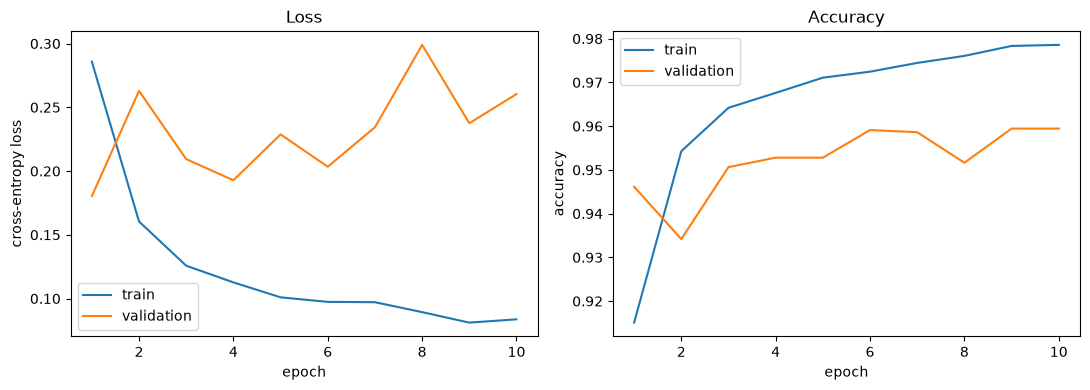

In [5]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"], label="validation")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"], label="validation")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

If training loss keeps falling while validation loss flattens out or rises, that
gap is overfitting: the model is fitting details specific to the training batches
rather than patterns that generalize. With this small model and dataset size the two
curves should stay fairly close together.

## 9. Evaluate on the test set

The test set was untouched during training and validation-based model development
above; we evaluate on it exactly once here.

In [6]:
model.eval()
with torch.no_grad():
    test_loss, test_acc = run_epoch(test_batches, model, None)
print(f"Test loss: {test_loss:.4f}   Test accuracy: {test_acc:.4f}")

Test loss: 0.2393   Test accuracy: 0.9660


## 10. Inspect predictions

A grid of test images together with their true label and the model's predicted
label, including a mix of correct and incorrect predictions where available.

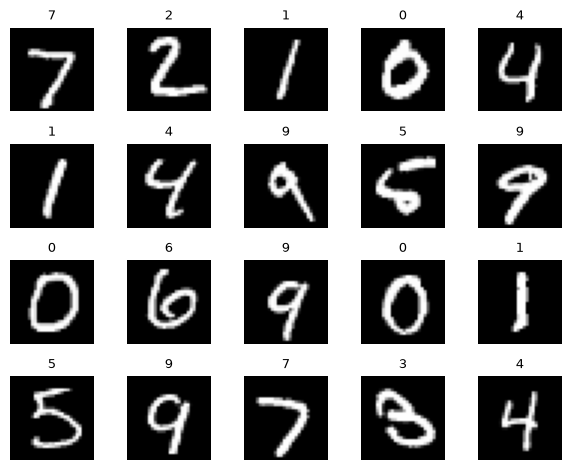

In [7]:
model.eval()
with torch.no_grad():
    sample_x = torch.tensor(test_x[:32], dtype=torch.float32)
    sample_y = test_y[:32]
    logits = model(sample_x)
    preds = torch.argmax(logits, dim=1).numpy()

correct_labels = [f"{p}" + ("" if p == t else f" (true {t})") for p, t in zip(preds, sample_y)]
plot_images(test_x[:20], labels=correct_labels[:20])

## Study questions

1. Why does a fully connected layer ignore the 2-D spatial arrangement after
   flattening?
2. What does a hidden layer learn that a linear classifier cannot?
3. How can training and validation curves reveal overfitting?